In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,recall_score,accuracy_score,precision_score,f1_score
import pickle


In [88]:
df = df = pd.read_csv("../data/raw/08-winequality-red.csv", sep=";")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [89]:
df.info()
df.isna().sum()
df.describe().T
df["quality"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [90]:
df.duplicated().sum()
df = df.drop_duplicates()



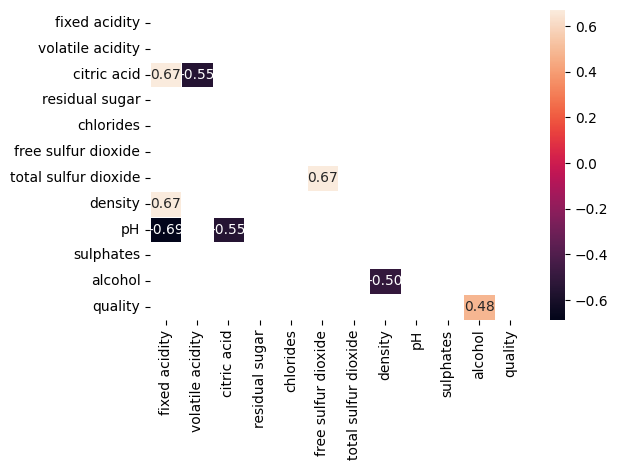

In [91]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.4]
significant_corr
sns.heatmap(significant_corr,mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()


In [92]:
fig = px.scatter_3d(df,
              x="citric acid",
              y="density",
              z="pH",
              color="quality")
fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True),
        yaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True),
        zaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True)
    )

)
fig.update_traces(marker=dict(size=3))
fig.show()


### Conclusiones



-Estas tres variables por sí solas no son buenos predictores de la calidad del vino. Sirven para explorar, pero el modelo necesita considerar más atributos para capturar la relación con la calidad.

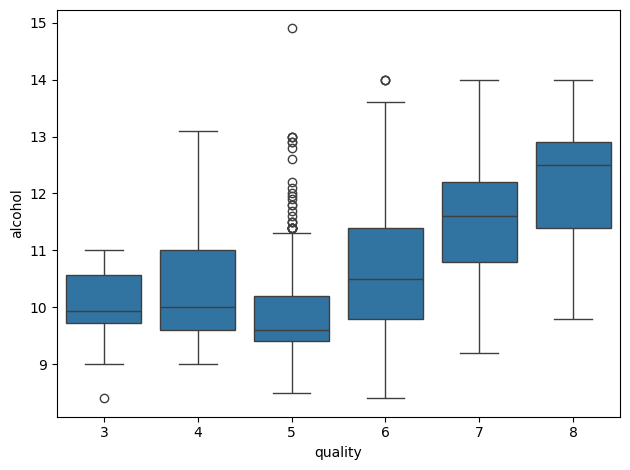

In [93]:
sns.boxplot(data=df,x="quality", y="alcohol")
plt.tight_layout()
plt.show()

### Conclusiones

-Este grafico muestra una relación directa entre alcohol y calidad del vino, a medida que sube la calidad, tambien sube la mediana de alcohol, los vinos mejor valorados tienden a teenr más alcohol.


In [94]:
df["target"]=pd.cut(df["quality"], bins=[2,4,6,8], labels=[0,1,2], include_lowest=True)
df["target"].value_counts()

/tmp/ipykernel_18980/40671140.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



target
1    1112
2     184
0      63
Name: count, dtype: int64

### Conclusiones

Agrupamos los nieveles de calidad del vino en tres categorias más generales
3 a 4 -> calidad baja
5 a 6 -> calidad media
7 a 8 -> calidad alta


In [95]:
X = df.drop(columns=["quality", "target"])
y = df["target"].astype(int) #Nos aseguramos que y sea numerica



In [96]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)
#stratify mantiene una distribucion de clases balanceada en test y train, es decir, 70% de vinos buenos, 20% de medios y asi.

In [97]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaler
X_train_scaled, X_test_scaled

(array([[ 0.19875528,  0.77120054, -0.87903384, ...,  0.01078313,
         -0.04940309, -0.8013678 ],
        [-0.42598628, -0.12386319, -0.62375471, ..., -0.89085284,
         -0.16794868, -0.20730997],
        [-0.70995972, -0.99180377,  0.09102685, ...,  0.7192114 ,
         -0.04940309,  0.52383813],
        ...,
        [ 0.14196059, -0.01537061, -0.26636393, ..., -0.69764513,
         -0.58285825, -0.20730997],
        [ 1.90259591, -0.4493409 ,  1.82692494, ..., -0.63324256,
          0.1876881 ,  0.43244462],
        [-0.08521816, -0.12386319, -0.16425228, ...,  0.20399084,
         -0.10867588, -0.84706456]], shape=(1087, 11)),
 array([[-0.36919159,  0.71695425, -1.3895921 , ..., -0.24682714,
          0.42477929, -1.02985158],
        [-0.14201284,  1.58489484, -0.16425228, ...,  0.39719855,
          0.66187047,  0.24965759],
        [-0.42598628, -1.31728149,  1.11214337, ...,  0.01078313,
         -0.28649427, -0.29870348],
        ...,
        [ 0.82349685, -1.04605006,  

### Conclusiones

-Utilizamos StandarScaler ya que creo que es la mejor opcion para un modelo como este que no asume normalidad pero si depende de distancias

In [98]:
model = KNeighborsClassifier()
model.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [99]:
params = {"n_neighbors":[3,5,7,9,11,13,15,17],
          "metric":["euclidean","manhattan","chebyshev","minkowski","cosine"],
          "weights":["uniform","distance"]}

search = GridSearchCV(model,params,cv=5,scoring="accuracy")

search.fit(X_train_scaled,y_train)
search.best_estimator_,search.score(X_test_scaled, y_test)

(KNeighborsClassifier(metric='cosine', n_neighbors=17, weights='distance'),
 0.8529411764705882)

In [100]:
y_pred_test = search.predict(X_test_scaled)
y_pred_train = search.predict(X_train_scaled)
y_pred_test

array([1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2])

array([[  0,  13,   0],
       [  0, 216,   6],
       [  0,  21,  16]])

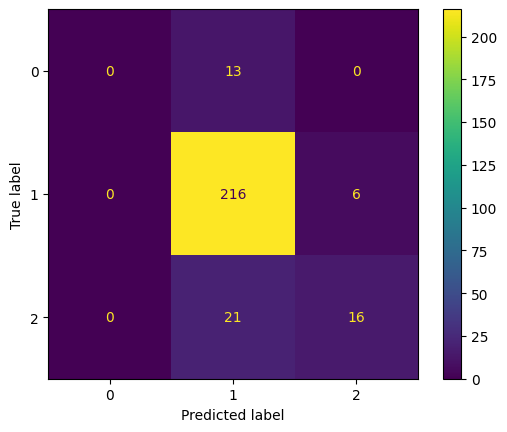

In [101]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay.from_estimator(search, X_test_scaled, y_test)
cm


In [102]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='micro'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

result = get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)
result


,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.852941,0.852941,0.852941,0.852941


In [103]:
with open('../models/model-k-nearest-neighbours-winequality-red.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/scaler-k-nearest-neighbours-winequality-redl', 'wb') as f:
    pickle.dump(scaler, f)

### Conclusiones

-Podemos observar una diferencia entre las metricas de train y test que nos puede indicar un posible data leakage o un error tecnico pero en este caso es la naturaleza del modelo, en entrenamiento memeoriza perfectamente los puntos uqe ya conoce pero al enfrentarse a ejemplos que no conoce depende de la similitud de los vecinos, es decir, el modelos nos está mostarndi qye puede distinguir cierta estructura en los datos pero que la frontera entre clases no es tan clara como para generalizar con total precision, lo que nos indica que podemos optar por modelos mas robustos

In [104]:
def predict_wine_quality(features, model, scaler):
    """
    Predice la calidad de un vino.
    
    Args:
        features: lista/array con las 11 características del vino
        model: modelo KNN entrenado
        scaler: scaler ajustado
    
    Returns:
        Categoría de calidad (0: baja, 1: media, 2: alta)
    """
    features_array = np.array(features).reshape(1, -1)
    features_scaled = scaler.transform(features_array)
    prediction = model.predict(features_scaled)
    
    categorias = {0: "Baja", 1: "Media", 2: "Alta"}
    return categorias[prediction[0]]

# Ejemplo de uso:
nuevo_vino = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
f"Calidad predicha: {predict_wine_quality(nuevo_vino, search.best_estimator_, scaler)}"

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



'Calidad predicha: Media'